# 📊 Prosperity Backtester Visualizer
Visualize your backtest results from the `.log` file generated by the backtester.

**Setup:** `pip install pandas matplotlib`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from io import StringIO
import json

# ── CONFIG — change this to your log file path ──────────────────────────────
LOG_FILE = "2026-04-16_08-42-08.log"   # <-- put your .log filename here
# ────────────────────────────────────────────────────────────────────────────

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0e1318',
    'axes.facecolor':   '#0e1318',
    'axes.edgecolor':   '#1c2a35',
    'axes.labelcolor':  '#b8ccd8',
    'xtick.color':      '#3a5060',
    'ytick.color':      '#3a5060',
    'grid.color':       '#1c2a35',
    'grid.linewidth':   0.5,
    'text.color':       '#b8ccd8',
    'font.family':      'monospace',
    'font.size':        9,
})
print(f"Config loaded. Log file: {LOG_FILE}")

Config loaded. Log file: 2026-04-16_08-42-08.log


In [2]:
# ── PARSE LOG FILE ───────────────────────────────────────────────────────────

def parse_log(path: str):
    with open(path, 'r', encoding='utf-8') as f:
        content = f.read()

    lines = content.replace('\r\n', '\n').split('\n')
    sep_idx = next(
        (i for i, l in enumerate(lines) if i > 0 and l.strip() == '' and
         i + 1 < len(lines) and lines[i + 1].strip().startswith('{')),
        len(lines)
    )
    act_lines = [l for l in lines[:sep_idx] if l.strip()]

    df = pd.read_csv(StringIO('\n'.join(act_lines)), sep=';')
    df.columns = df.columns.str.strip()

    num_cols = ['bid_price_1','bid_volume_1','bid_price_2','bid_volume_2',
                'bid_price_3','bid_volume_3','ask_price_1','ask_volume_1',
                'ask_price_2','ask_volume_2','ask_price_3','ask_volume_3',
                'mid_price','profit_and_loss']
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    df['global_ts'] = df['day'] * 1_000_000 + df['timestamp']
    df = df.sort_values(['global_ts', 'product']).reset_index(drop=True)

    # KEY FIX: drop rows where mid_price == 0
    # When the order book is one-sided, mid_price = 0 which makes
    # PnL = cash + position * 0 — completely wrong, causing huge spikes.
    n_before = len(df)
    df = df[df['mid_price'] > 0].copy()
    print(f"  Dropped {n_before - len(df)} rows with mid_price = 0 (one-sided order book)")

    return df


df = parse_log(LOG_FILE)
products = sorted(df['product'].unique())
days     = sorted(df['day'].unique())

COLORS = {
    'ASH_COATED_OSMIUM':    '#39ff8f',
    'INTARIAN_PEPPER_ROOT': '#a78bfa',
}

print(f"Products: {products}")
print(f"Days    : {days}")
df.head()

  Dropped 103 rows with mid_price = 0 (one-sided order book)
Products: ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
Days    : [np.int64(-2), np.int64(-1), np.int64(0)]


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_ts
0,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,-2000000
1,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,-2000000
2,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,-1999900
3,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,-1999900
4,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0,-1999800


In [3]:
# ── SUMMARY STATS ────────────────────────────────────────────────────────────

# pivot: one PnL value per (global_ts x product), forward-fill gaps
pnl_pivot = df.pivot_table(
    index='global_ts', columns='product',
    values='profit_and_loss', aggfunc='last'
).ffill()

pnl_pivot['TOTAL'] = pnl_pivot[list(products)].sum(axis=1)

final_pnl = pnl_pivot['TOTAL'].iloc[-1]
peak      = pnl_pivot['TOTAL'].cummax()
drawdown  = peak - pnl_pivot['TOTAL']
max_dd    = drawdown.max()

print("=" * 50)
print(f"  FINAL PnL       : {final_pnl:>12,.2f}")
print(f"  MAX DRAWDOWN    : {-max_dd:>12,.2f}")
print("-" * 50)
for p in products:
    if p in pnl_pivot.columns:
        print(f"  {p:<30} {pnl_pivot[p].iloc[-1]:>10,.2f}")
print("-" * 50)
print(f"  Days tested     : {days}")
print("=" * 50)

  FINAL PnL       :    40,113.00
  MAX DRAWDOWN    :      -784.00
--------------------------------------------------
  ASH_COATED_OSMIUM               13,626.00
  INTARIAN_PEPPER_ROOT            26,487.00
--------------------------------------------------
  Days tested     : [np.int64(-2), np.int64(-1), np.int64(0)]


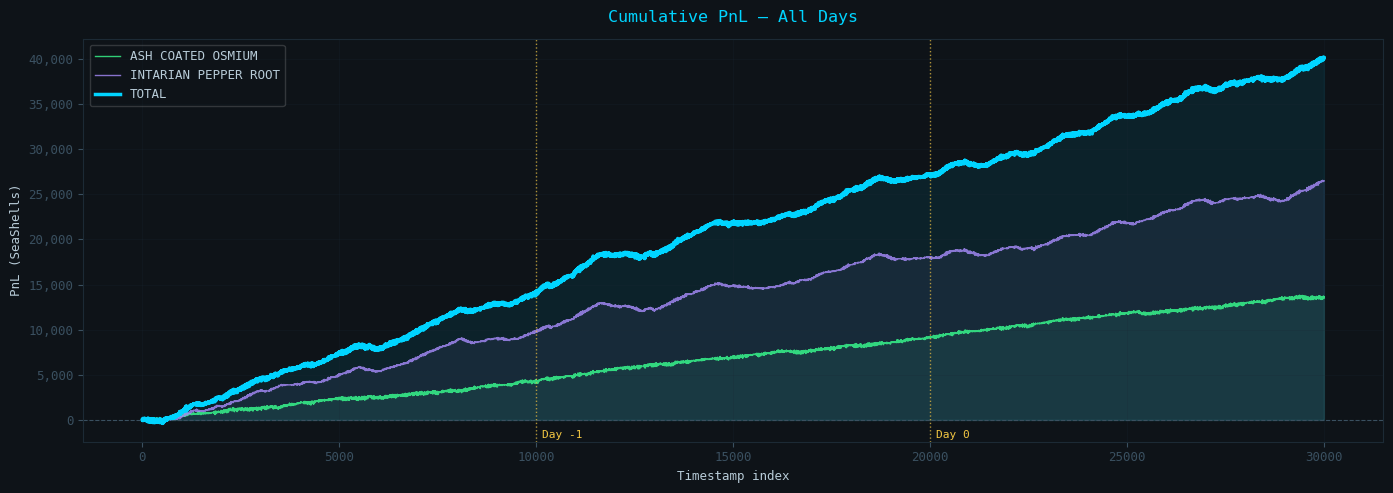

In [4]:
# ── CHART 1: CUMULATIVE PnL ─────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0e1318')
xs = range(len(pnl_pivot))

for p in products:
    if p in pnl_pivot.columns:
        color = COLORS.get(p, '#ffffff')
        ax.plot(list(xs), pnl_pivot[p].values, color=color, lw=1, alpha=0.8,
                label=p.replace('_', ' '))
        ax.fill_between(list(xs), pnl_pivot[p].values, alpha=0.08, color=color)

ax.plot(list(xs), pnl_pivot['TOTAL'].values, color='#00d4ff', lw=2.5,
        label='TOTAL', zorder=5)
ax.fill_between(list(xs), pnl_pivot['TOTAL'].values, alpha=0.08, color='#00d4ff')
ax.axhline(0, color='#3a5060', lw=0.8, linestyle='--')

# Day boundaries
for day in days[1:]:
    day_min_gts = df[df['day'] == day]['global_ts'].min()
    idx_list    = [i for i, v in enumerate(pnl_pivot.index) if v == day_min_gts]
    if idx_list:
        idx = idx_list[0]
        ax.axvline(idx, color='#f5c842', lw=1, linestyle=':', alpha=0.7)
        ax.text(idx + len(xs)*0.005, ax.get_ylim()[0] * 0.85 if ax.get_ylim()[0] < 0 else 0,
                f'Day {day}', color='#f5c842', fontsize=8)

ax.set_title('Cumulative PnL — All Days', color='#00d4ff', pad=12, fontsize=12)
ax.set_ylabel('PnL (SeaShells)')
ax.set_xlabel('Timestamp index')
ax.legend(loc='upper left', framealpha=0.2, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

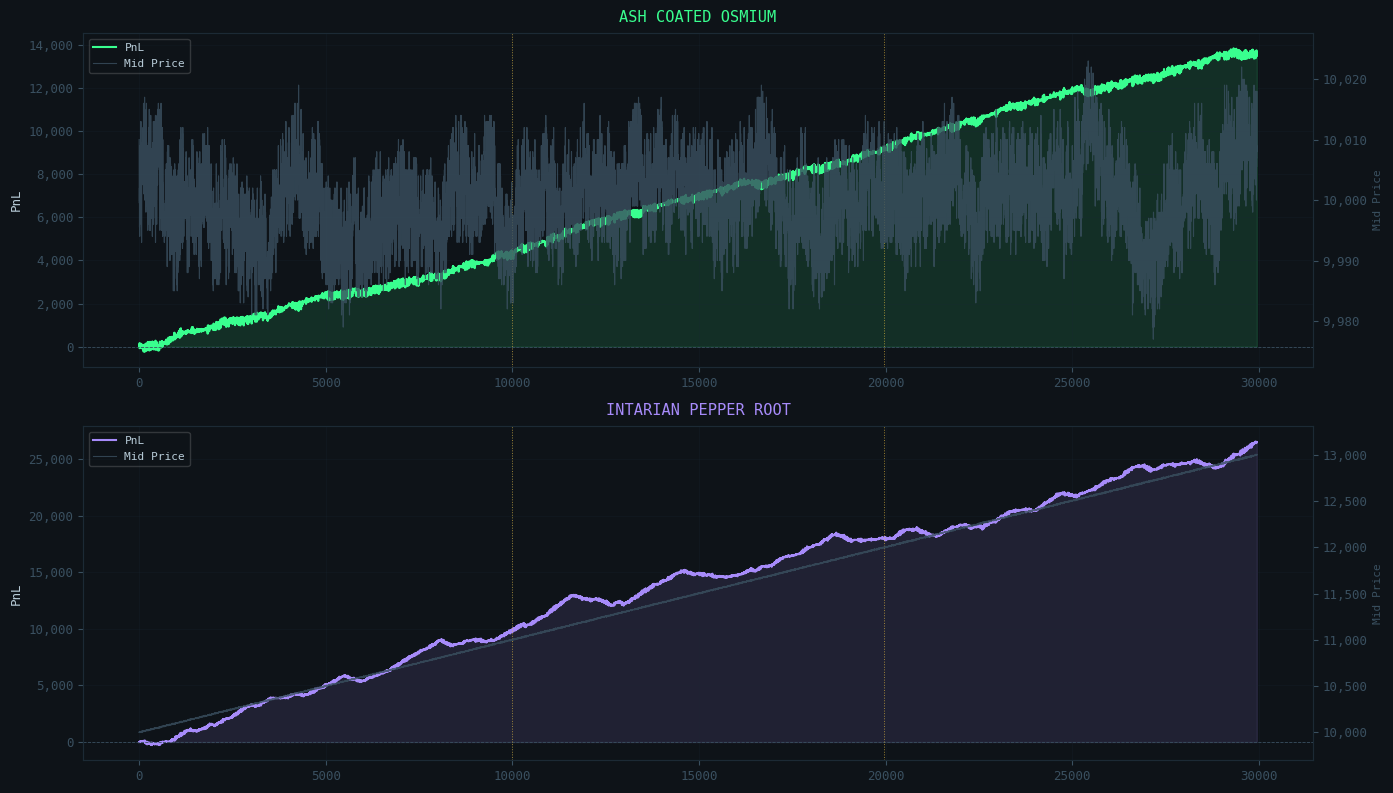

In [5]:
# ── CHART 2: PER-PRODUCT PnL + MID PRICE ────────────────────────────────────

fig, axes = plt.subplots(len(products), 1, figsize=(14, 4 * len(products)))
fig.patch.set_facecolor('#0e1318')
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    color = COLORS.get(product, '#00d4ff')
    pdf   = df[df['product'] == product].copy().reset_index(drop=True)
    xs    = range(len(pdf))

    # Mid price — right axis, proper range
    mid_min = pdf['mid_price'].min()
    mid_max = pdf['mid_price'].max()
    mid_pad = (mid_max - mid_min) * 0.1 or 10

    ax2 = ax.twinx()
    ax2.plot(xs, pdf['mid_price'].values, color='#3a5060', lw=0.8, alpha=0.8,
             label='Mid Price')
    ax2.set_ylim(mid_min - mid_pad, mid_max + mid_pad)
    ax2.set_ylabel('Mid Price', color='#3a5060', fontsize=8)
    ax2.tick_params(axis='y', colors='#3a5060')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # PnL — left axis
    ax.plot(xs, pdf['profit_and_loss'].values, color=color, lw=1.5, label='PnL')
    ax.fill_between(xs, pdf['profit_and_loss'].values, alpha=0.12, color=color)
    ax.axhline(0, color='#3a5060', lw=0.6, linestyle='--')

    # Day boundaries
    for day in days[1:]:
        first = pdf[pdf['day'] == day].index
        if len(first):
            ax.axvline(first[0], color='#f5c842', lw=0.7, linestyle=':', alpha=0.6)

    ax.set_title(product.replace('_', ' '), color=color, pad=8, fontsize=11)
    ax.set_ylabel('PnL')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(True, alpha=0.3)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              loc='upper left', framealpha=0.2, fontsize=8)

plt.tight_layout()
plt.show()

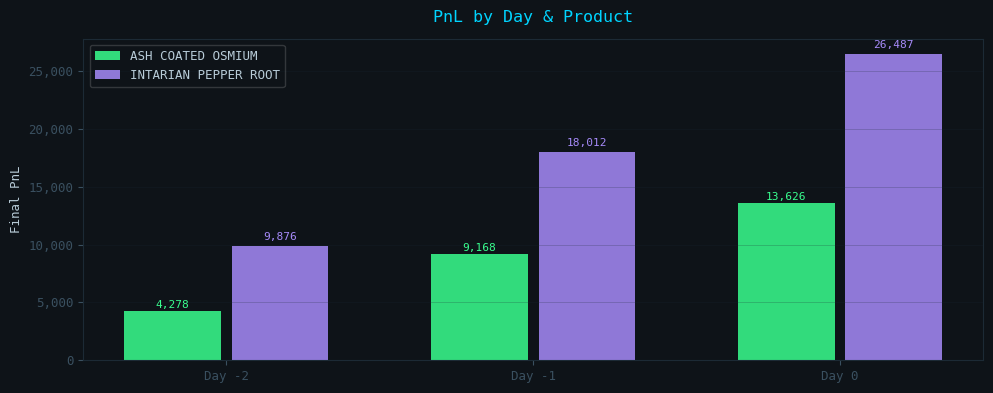


PnL per day per product:
product  ASH_COATED_OSMIUM  INTARIAN_PEPPER_ROOT     TOTAL
day                                                       
-2                4,278.00              9,876.00 14,154.00
-1                9,168.00             18,012.00 27,180.00
 0               13,626.00             26,487.00 40,113.00


In [6]:
# ── CHART 3: PER-DAY BREAKDOWN ───────────────────────────────────────────────

day_summary = []
for day in days:
    for p in products:
        sub = df[(df['day'] == day) & (df['product'] == p)]
        if len(sub):
            day_summary.append({'day': day, 'product': p,
                                'final_pnl': sub['profit_and_loss'].iloc[-1]})

summary_df = pd.DataFrame(day_summary)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0e1318')

x = range(len(days))
w = 0.35
for i, p in enumerate(products):
    color  = COLORS.get(p, '#ffffff')
    vals   = [summary_df[(summary_df['day']==d) & (summary_df['product']==p)]['final_pnl'].values
              for d in days]
    vals   = [float(v[0]) if len(v) else 0.0 for v in vals]
    offset = (i - len(products)/2 + 0.5) * w
    ax.bar([xi + offset for xi in x], vals, width=w*0.9,
           color=color, alpha=0.85, label=p.replace('_', ' '))
    for xi, v in zip(x, vals):
        ax.text(xi + offset, v + max(vals)*0.02 if v >= 0 else v - max(vals)*0.06,
                f'{v:,.0f}', ha='center', fontsize=8, color=color)

ax.set_xticks(list(x))
ax.set_xticklabels([f'Day {d}' for d in days])
ax.set_title('PnL by Day & Product', color='#00d4ff', pad=12, fontsize=12)
ax.set_ylabel('Final PnL')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(framealpha=0.2, fontsize=9)
ax.axhline(0, color='#3a5060', lw=0.6)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPnL per day per product:")
pivot = summary_df.pivot(index='day', columns='product', values='final_pnl')
pivot['TOTAL'] = pivot.sum(axis=1)
print(pivot.to_string(float_format=lambda x: f'{x:,.2f}'))

In [ ]:
# ── CHART 4: BID/ASK SPREAD OVER TIME ───────────────────────────────────────

fig, axes = plt.subplots(len(products), 1, figsize=(14, 3 * len(products)))
fig.patch.set_facecolor('#0e1318')
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    color = COLORS.get(product, '#00d4ff')
    pdf   = df[df['product'] == product].copy().reset_index(drop=True)
    pdf['spread'] = pdf['ask_price_1'] - pdf['bid_price_1']
    valid = pdf[pdf['spread'].notna() & (pdf['spread'] > 0)]

    ax.plot(valid.index, valid['spread'].values, color=color, lw=0.8, alpha=0.7)
    ax.fill_between(valid.index, valid['spread'].values, alpha=0.12, color=color)

    avg = valid['spread'].mean()
    ax.axhline(avg, color='#f5c842', lw=1, linestyle='--',
               label=f'Avg spread: {avg:.1f}')

    ax.set_title(f'{product.replace("_"," ")} — Bid/Ask Spread', color=color, fontsize=11)
    ax.set_ylabel('Spread')
    ax.legend(framealpha=0.2, fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

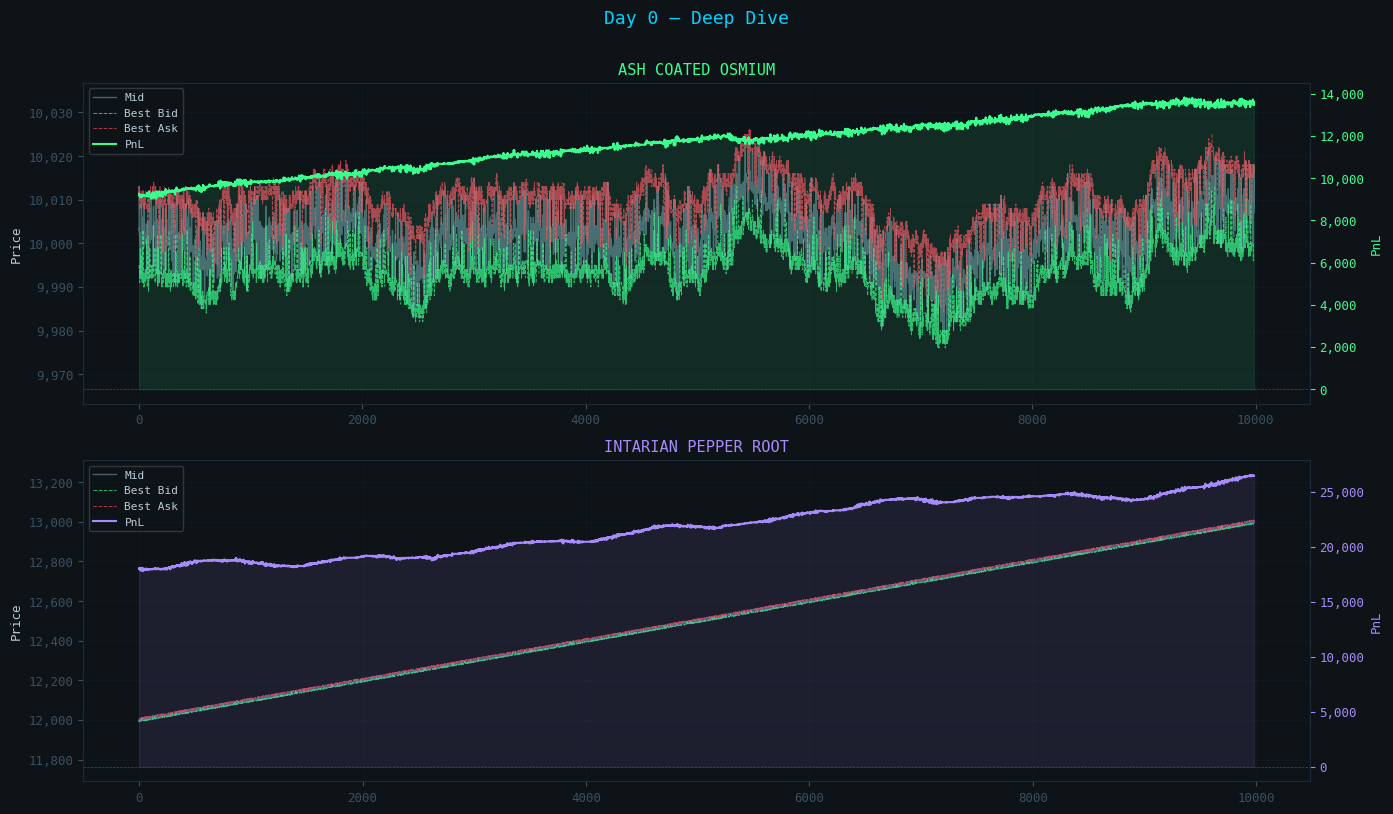

In [7]:
# ── CHART 5: SINGLE DAY DEEP DIVE ───────────────────────────────────────────
# Change DAY to zoom into a specific day

DAY = 0   # <-- change to -2, -1, or 0

day_df = df[df['day'] == DAY]
if len(day_df) == 0:
    print(f"Day {DAY} not found. Available: {days}")
else:
    fig, axes = plt.subplots(len(products), 1, figsize=(14, 4 * len(products)))
    fig.patch.set_facecolor('#0e1318')
    fig.suptitle(f'Day {DAY} — Deep Dive', color='#00d4ff', fontsize=13, y=1.01)
    if len(products) == 1:
        axes = [axes]

    for ax, product in zip(axes, products):
        color = COLORS.get(product, '#00d4ff')
        pdf   = day_df[day_df['product'] == product].copy().reset_index(drop=True)
        xs    = range(len(pdf))

        # Price axis — zoomed to actual price range
        mid_min = pdf['mid_price'].min()
        mid_max = pdf['mid_price'].max()
        mid_pad = (mid_max - mid_min) * 0.3 or 5

        ax.plot(xs, pdf['mid_price'].values, color='#4a6070', lw=1, label='Mid')
        ax.plot(xs, pdf['bid_price_1'].values, color='#39ff8f', lw=0.7,
                alpha=0.7, linestyle='--', label='Best Bid')
        ax.plot(xs, pdf['ask_price_1'].values, color='#ff4560', lw=0.7,
                alpha=0.7, linestyle='--', label='Best Ask')
        ax.set_ylim(mid_min - mid_pad, mid_max + mid_pad)
        ax.set_ylabel('Price')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

        # PnL — right axis
        ax2 = ax.twinx()
        ax2.plot(xs, pdf['profit_and_loss'].values, color=color, lw=1.5, label='PnL')
        ax2.fill_between(xs, pdf['profit_and_loss'].values, alpha=0.1, color=color)
        ax2.axhline(0, color='#3a5060', lw=0.5, linestyle='--')
        ax2.set_ylabel('PnL', color=color, fontsize=9)
        ax2.tick_params(axis='y', colors=color)
        ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

        ax.set_title(product.replace('_', ' '), color=color, fontsize=11)
        ax.grid(True, alpha=0.3)
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2,
                  loc='upper left', framealpha=0.2, fontsize=8)

    plt.tight_layout()
    plt.show()